# Chicago Risk District Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt

In [2]:
from sys import path

path.insert(0, '../modules')

import utils as f
import params_cfg as pc
import visuals

colors = pc.COLORS
gen_theft = pc.GENERAL_THFT
gen_aslt = pc.GENERAL_ASLT
census_data = pc.CENSUS_DATA

%load_ext autoreload
%autoreload 2

In [3]:
# defining the project paths
brz_path = pc.BRZ_PATH
slv_path = pc.SLV_PATH
gld_path = pc.GLD_PATH
img_path = pc.IMG_PATH
model_path = pc.MODEL_PATH

In [48]:
df_crime = pd.read_csv(
    f'{slv_path}/df_crime_final.csv',
    index_col='date',
    parse_dates=True
)

df_crime['district'] = df_crime['district'].astype(str)
df_crime['ddate'] = pd.to_datetime(df_crime.index.date)

df_crime.head()

,id,arrest,domestic,district,community_area,crime_group,crime_distance,min_dist_station,max_dist_station,avg_cm_area,...,avg_per_capita_income,avg_hardship_index,pct_housing_crowded,pct_hh_below_pvty,pct_16_unemployed,pct_25_without_hsd,pct_dependents,per_capita_income,hardship_index,ddate
date,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:03:00,12581802,0,0,10,29,ASLT,1.852004,1.852004,21.823778,129.112315,...,20979.833333,63.166667,0.074,0.431,0.212,0.276,0.427,12034.0,87,2022-01-01
2022-01-01 00:04:00,12582232,0,0,12,28,ASLT,2.659790,2.659790,22.031854,78.080901,...,38318.700000,40.500000,0.038,0.206,0.107,0.096,0.222,44689.0,15,2022-01-01
2022-01-01 00:05:00,12582704,0,0,9,61,ASLT,3.327426,3.327426,20.750551,74.037276,...,19866.333333,69.466667,0.119,0.290,0.230,0.415,0.389,12765.0,91,2022-01-01
2022-01-01 00:05:00,12581815,0,0,11,26,ASLT,2.124182,2.124182,23.549729,109.321992,...,21936.285714,63.571429,0.094,0.417,0.258,0.245,0.436,10934.0,92,2022-01-01
2022-01-01 00:05:00,12582341,0,0,4,48,ASLT,3.104587,3.104587,30.775613,95.610774,...,18437.833333,61.333333,0.021,0.115,0.200,0.110,0.440,28887.0,38,2022-01-01


## Daily Count

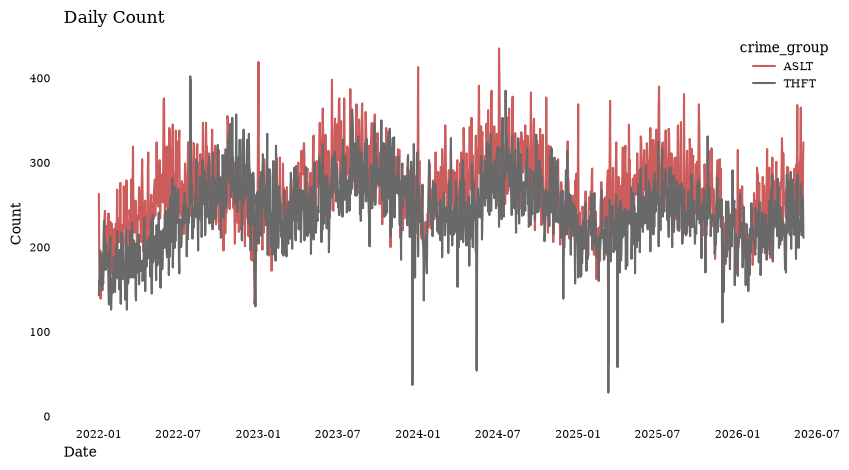

In [49]:
grp = df_crime[['ddate', 'crime_group', 'id']]\
    .groupby(['ddate', 'crime_group'])\
    .count()\
    .reset_index()

sns.lineplot(
    data=grp,
    x='ddate',
    y='id',
    hue='crime_group',
    palette=colors
)

plt.ylim(0)
plt.title('Daily Count', loc='left')
plt.ylabel('Count')
plt.xlabel('Date', loc='left')
plt.box(False);

## Moving Average

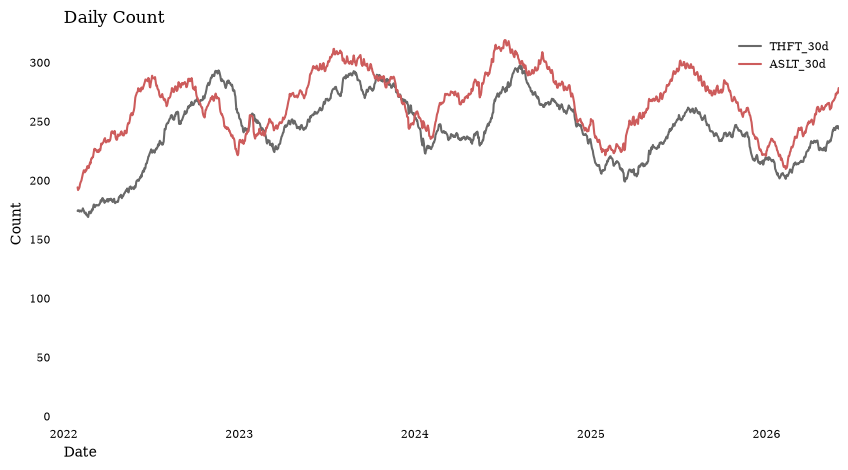

In [65]:
grp = df_crime[['ddate', 'crime_group', 'id']]\
    .groupby(['ddate', 'crime_group'])\
    .count()\
    .reset_index()


grp_aslt = grp.query('crime_group == "ASLT"').copy()
grp_thft = grp.query('crime_group == "THFT"').copy()

k = 30
grp_aslt[f'ASLT_{k}d'] = grp_aslt['id'].rolling(k).mean()
grp_thft[f'THFT_{k}d'] = grp_thft['id'].rolling(k).mean()

grp_ma = grp_thft[['ddate', f'THFT_{k}d']].merge(
    grp_aslt[['ddate', f'ASLT_{k}d']],
    how='inner',
    on='ddate'
)

grp_ma.plot(
    x='ddate',
    color=list(colors.values())
)

plt.ylim(0)
plt.title('Daily Count', loc='left')
plt.ylabel('Count')
plt.xlabel('Date', loc='left')
plt.box(False);

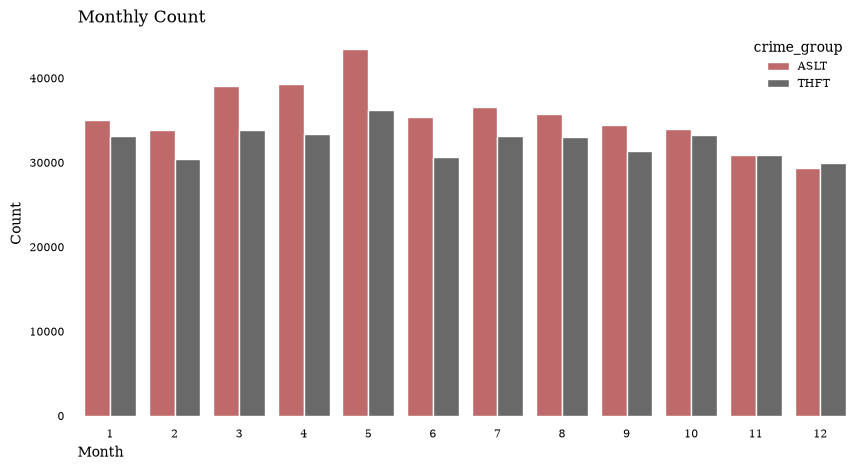

In [64]:
df_crime['month'] = df_crime['ddate'].dt.month

grp = df_crime[['month', 'crime_group', 'id']]\
    .groupby(['month', 'crime_group'])\
    .count()\
    .reset_index()


sns.barplot(
    data=grp,
    x='month',
    y='id',
    hue='crime_group',
    palette=colors
)

plt.title('Monthly Count', loc='left')
plt.ylabel('Count')
plt.xlabel('Month', loc='left')
plt.box(False);

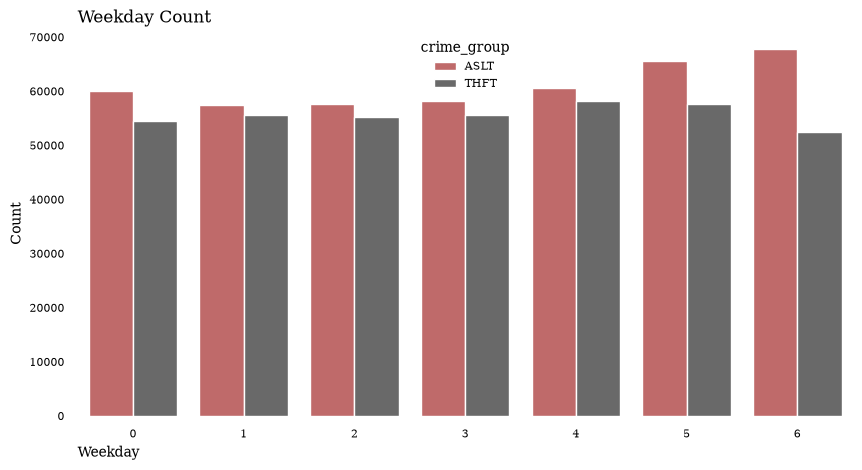

In [67]:
df_crime['weekday'] = df_crime['ddate'].dt.weekday

grp = df_crime[['weekday', 'crime_group', 'id']]\
    .groupby(['weekday', 'crime_group'])\
    .count()\
    .reset_index()


sns.barplot(
    data=grp,
    x='weekday',
    y='id',
    hue='crime_group',
    palette=colors
)

plt.title('Weekday Count', loc='left')
plt.ylabel('Count')
plt.xlabel('Weekday', loc='left')
plt.box(False);